# Imports

In [2]:
import numpy as np
import ripser
import gudhi as gd
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

# Henon map

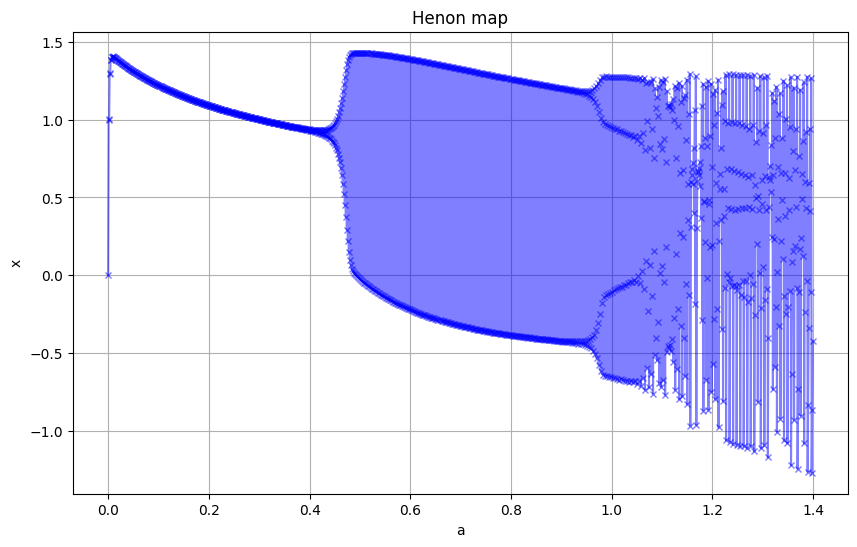

In [2]:
# parameters
b = 0.3
sigma = 0.01
step = 0.001
n_points = 1400

# initialize arrays
x = np.zeros(n_points)
y = np.zeros(n_points)
a = np.zeros(n_points)
gaussian_noise = np.random.normal(0, 1, n_points)

# compute henon map with varying 'a' parameter
for i in range(1, n_points):
    x[i] = 1 - a[i-1] * x[i-1]**2 + b * y[i-1] + sigma * gaussian_noise[i-1] * np.sqrt(step)
    y[i] = x[i-1] + sigma * gaussian_noise[i-1] * np.sqrt(step) 
    a[i] = a[i-1] + step

# plot the trajectory (x vs a) with dots connected by lines
plt.figure(figsize=(10, 6))
plt.plot(a, x, marker='x', markersize=4, linestyle='-', color='blue', alpha=0.5)
plt.title("Henon map")
plt.xlabel("a")
plt.ylabel("x")
plt.grid()
plt.show()

c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


Text(0.5, 1.0, 'Persistence Diagram of Last Sliding Window')

<Figure size 800x600 with 0 Axes>

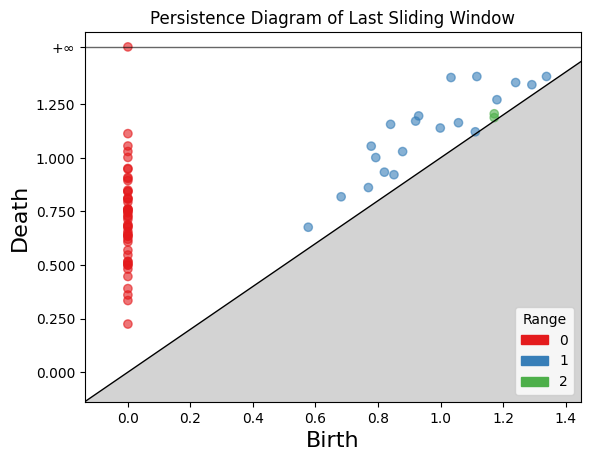

In [3]:
w = 50
b_values = [0.27, 0.28, 0.29, 0.3]

x = np.zeros((n_points, len(b_values)))
y = np.zeros((n_points, len(b_values)))
a = np.zeros((n_points, len(b_values)))
gaussian_noise = np.random.normal(0, 1, (n_points, len(b_values)))

for j, b in enumerate(b_values):
    for i in range(1, n_points):
        x[i, j] = 1 - a[i-1, j] * x[i-1, j]**2 + b * y[i-1, j] + sigma * gaussian_noise[i-1, j] * np.sqrt(step)
        y[i, j] = x[i-1, j] + sigma * gaussian_noise[i-1, j] * np.sqrt(step) 
        a[i, j] = a[i-1, j] + step

# compute the persistence diagrams of this 4D for every sliding window
diagrams = []
for i in range(n_points - w):
    window = x[i:i+w, :]  # shape (w, 4)
    rips = ripser.ripser(window, maxdim=2)
    diagrams.append(rips['dgms'])

# plot the persistence diagram of the last sliding window
plt.figure(figsize=(8, 6))
gd.plot_persistence_diagram(diagrams[-1])
plt.title("Persistence Diagram of Last Sliding Window")

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

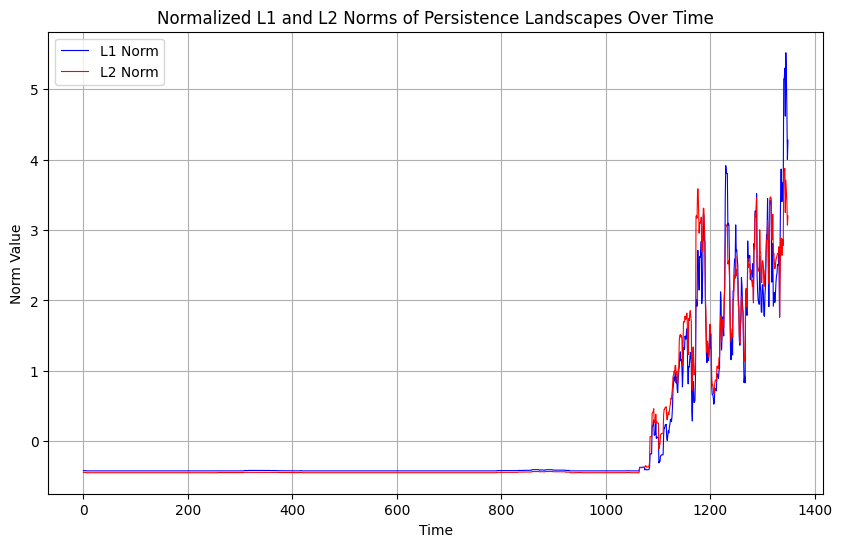

In [ ]:
# plot the L^1 and L^2 norms of the persistence landscapes over time on the same plot
import gudhi.representations as grepr

l1_norms = []
l2_norms = []
for diag in diagrams:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms.append(np.sum(np.abs(landscape)))
    l2_norms.append(np.sqrt(np.sum(landscape**2)))

# min-max normalize the norms
l1_norms = (np.array(l1_norms) - np.min(l1_norms)) / (np.max(l1_norms) - np.min(l1_norms) + 1e-10)
l2_norms = (np.array(l2_norms) - np.min(l2_norms)) / (np.max(l2_norms) - np.min(l2_norms) + 1e-10)

plt.figure(figsize=(10, 6))
plt.plot(l1_norms, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(l2_norms, label='L2 Norm', color='red', linewidth=0.8)
plt.title("Normalized L1 and L2 Norms of Persistence Landscapes Over Time")
plt.xlabel("Time")
plt.ylabel("Norm Value")
plt.legend()
plt.grid()

# Ising model

In [59]:
# generate a vector representing m steps of a 2D Ising model with interactions at a given temperature. Return all the steps as a m -length vector of n^2 vectors

def ising_model_2d(n, m, temperature):
    def metropolis_step(spins, beta):
        for _ in range(n * n):
            i = np.random.randint(0, n)
            j = np.random.randint(0, n)
            delta_E = 2 * spins[i, j] * (
                spins[(i + 1) % n, j] + spins[(i - 1) % n, j] +
                spins[i, (j + 1) % n] + spins[i, (j - 1) % n]
            )
            if delta_E < 0 or np.random.rand() < np.exp(-beta * delta_E):
                spins[i, j] *= -1
        return spins

    beta = 1.0 / temperature
    spins = np.random.choice([-1, 1], size=(n, n))
    configurations = []

    for _ in range(m):
        spins = metropolis_step(spins, beta)
        configurations.append(spins.copy().flatten())

    # return last configuration as a numpy array
    return np.array(configurations[-1])

In [87]:
X = np.zeros((1000, 100))
tempratures = np.linspace(1, 5, 1000)
for i, T in enumerate(tempratures):
    X[i] = ising_model_2d(10, 100, T).flatten()
print(X.shape)

(1000, 100)


In [88]:
# compute persistence diagrams for the Ising model configurations using sliding windows
w = 50
diagrams_ising = []
for i in range(X.shape[0] - w):
    window = X[i:i+w, :]  # shape (w, n^2)
    rips = ripser.ripser(window, maxdim=2)
    diagrams_ising.append(rips['dgms'])

c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more col

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

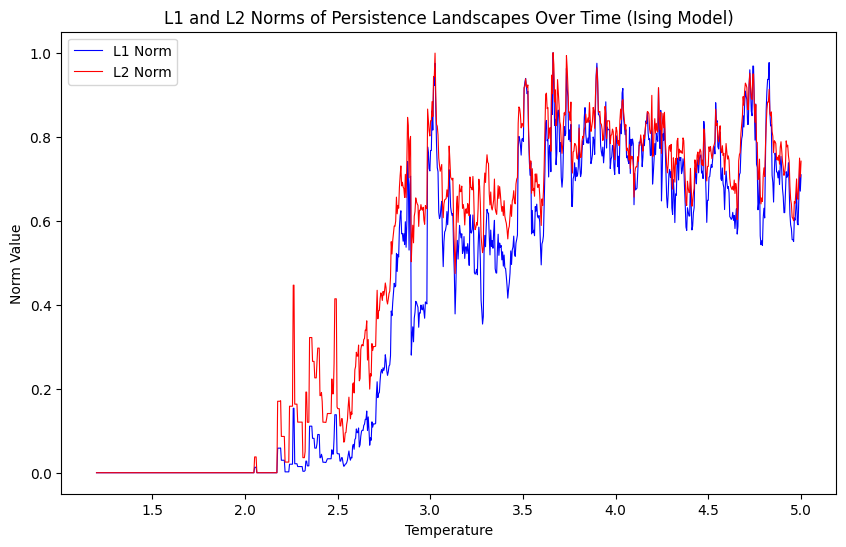

In [90]:
# plot the L^1 and L^2 norms of the persistence landscapes over time on the same plot

import gudhi.representations as grepr

l1_norms_ising = []
l2_norms_ising = []

for diag in diagrams_ising:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms_ising.append(np.sum(np.abs(landscape)))
    l2_norms_ising.append(np.sqrt(np.sum(landscape**2)))

# normalize the norms between 0 and 1
l1_norms_ising = (np.array(l1_norms_ising) - np.min(l1_norms_ising)) / (np.max(l1_norms_ising) - np.min(l1_norms_ising) + 1e-10)
l2_norms_ising = (np.array(l2_norms_ising) - np.min(l2_norms_ising)) / (np.max(l2_norms_ising) - np.min(l2_norms_ising) + 1e-10)

plt.figure(figsize=(10, 6))
plt.plot(tempratures[w:], l1_norms_ising, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(tempratures[w:], l2_norms_ising, label='L2 Norm', color='red', linewidth=0.8)
plt.title("L1 and L2 Norms of Persistence Landscapes Over Time (Ising Model)")
plt.xlabel("Temperature")
plt.ylabel("Norm Value")
plt.legend()
plt.show()

# White noise with Gamma-distributed inverse variance

In [6]:
X = []
num_clouds = 100
points_per_cloud = 100
scale_param = 8.0
beta_param = 1.0
M = 100 # number of Monte Carlo simulations

l1_norms_mc = []

for _ in range(M):
    X = []
    scale_param = 8.0
    for i in range(num_clouds):
        if i >= 75:
            scale_param -= 0.25
        variances = np.random.gamma(shape=2.0, scale=scale_param, size=4)
        std_devs = np.sqrt(1 / variances)
        cloud = np.random.normal(loc=0.0, scale=std_devs, size=(points_per_cloud, 4))
        X.append(cloud)
    
    diagrams_mc = []
    for cloud in X:
        rips = ripser.ripser(cloud)
        diagrams_mc.append(rips['dgms'])

    l1_norms_temp = []
    for diag in diagrams_mc:
        pl = grepr.Landscape(num_landscapes=10, resolution=500)
        landscape = pl.fit_transform([diag[1]])[0]
        l1_norms_temp.append(np.sum(np.abs(landscape)))
    l1_norms_mc.append(l1_norms_temp)
    
l1_norms_mc = np.array(l1_norms_mc)
l1_norms = np.mean(l1_norms_mc, axis=0)
l1_norms = (l1_norms - np.mean(l1_norms)) / np.std(l1_norms)


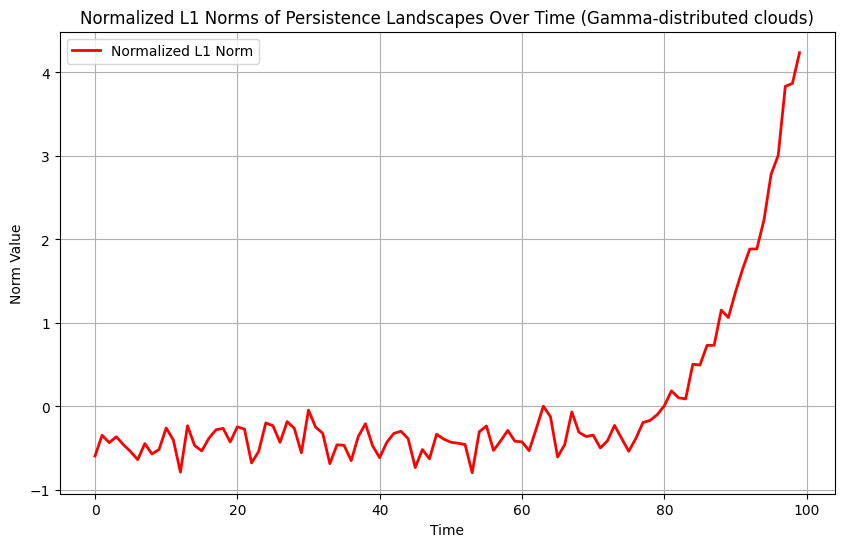

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(l1_norms, label='Normalized L1 Norm', color='red', linewidth=2)
plt.title("Normalized L1 Norms of Persistence Landscapes Over Time (Gamma-distributed clouds)")
plt.xlabel("Time")
plt.ylabel("Norm Value")
plt.legend()
plt.grid()
plt.show()

# Empirical analysis of financial data

In [10]:
# We analyze the daily time series of four major US stock market indices: S&P 500, DJIA, NASDAQ, Russel 2000? and VIX between December 23, 1987 and December 08, 2016 (7301 trading days). The times series data were downloaded from Yahoo Finance

tickers = ['^GSPC', '^DJI', '^IXIC', '^RUT', '^VIX']
data = yf.download(tickers, start='1987-12-23', end='2022-12-08')['Close']

C:\Users\eliot\AppData\Local\Temp\ipykernel_2096\975172653.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='1987-12-23', end='2022-12-08')['Close']
[*********************100%***********************]  5 of 5 completed


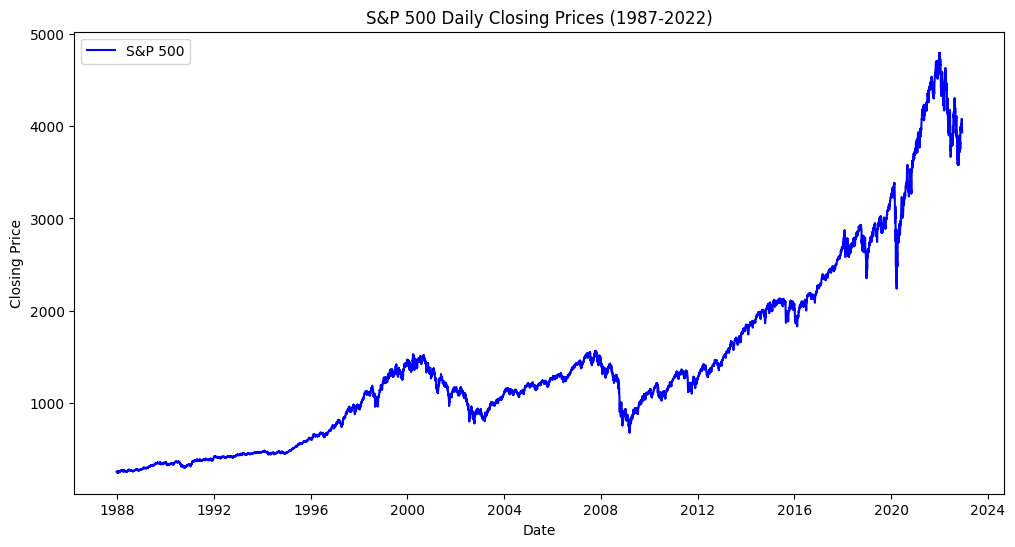

In [11]:
# plot SP500 time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['^GSPC'], label='S&P 500', color='blue')
plt.title("S&P 500 Daily Closing Prices (1987-2022)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

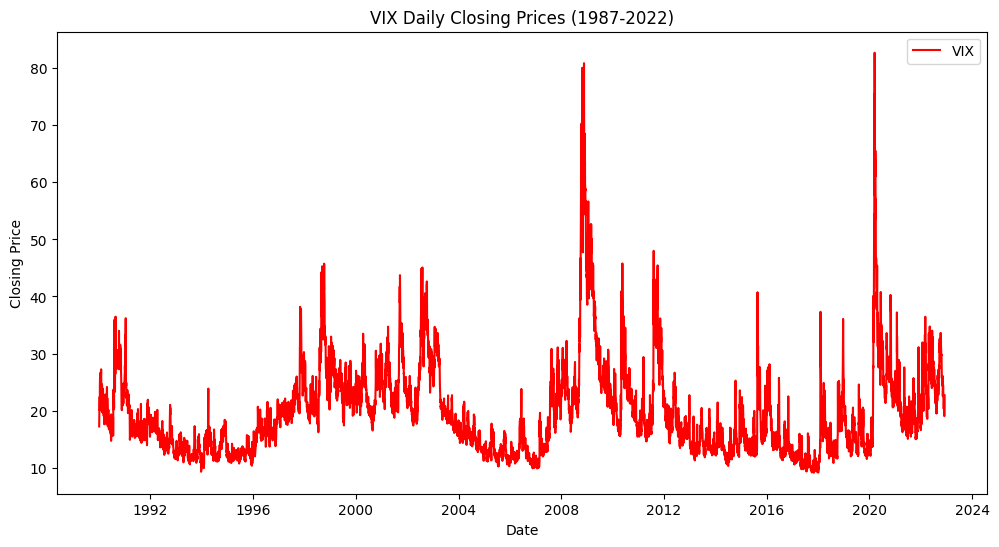

In [12]:
# plot VIX time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['^VIX'], label='VIX', color='red')
plt.title("VIX Daily Closing Prices (1987-2022)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.show()

In [13]:
# calculate log returns for all tickers except VIX
log_returns = np.log(data[tickers[:-1]] / data[tickers[:-1]].shift(1)).dropna()

 24%|██▍       | 1860/7692 [00:03<00:10, 531.12it/s]

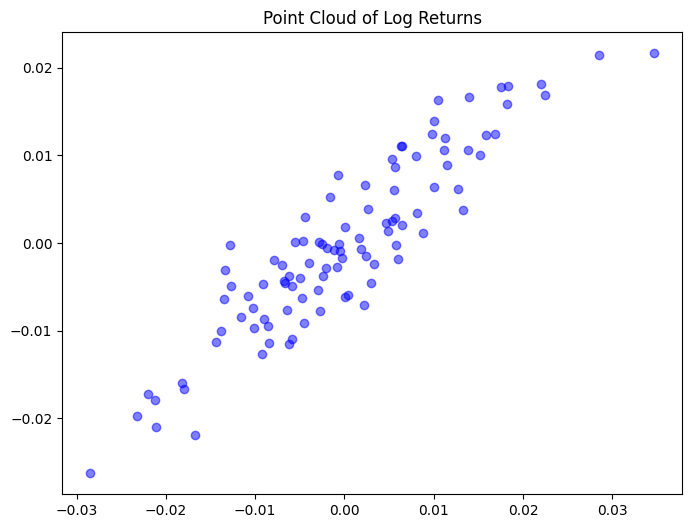

 50%|█████     | 3866/7692 [00:07<00:08, 462.21it/s]

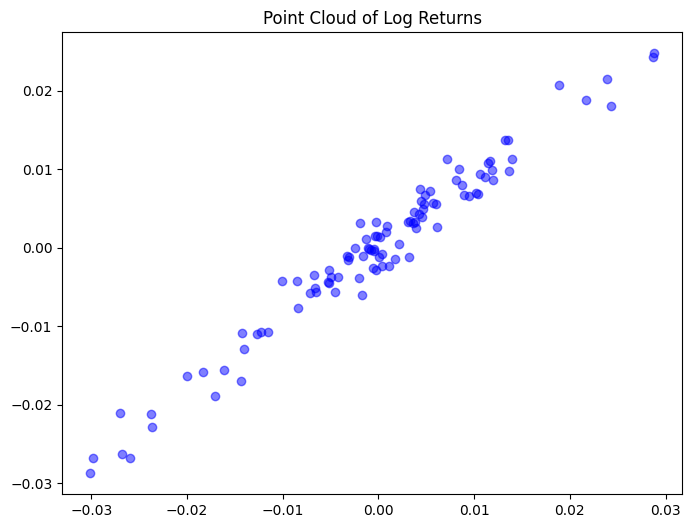

 77%|███████▋  | 5888/7692 [00:11<00:03, 480.78it/s]

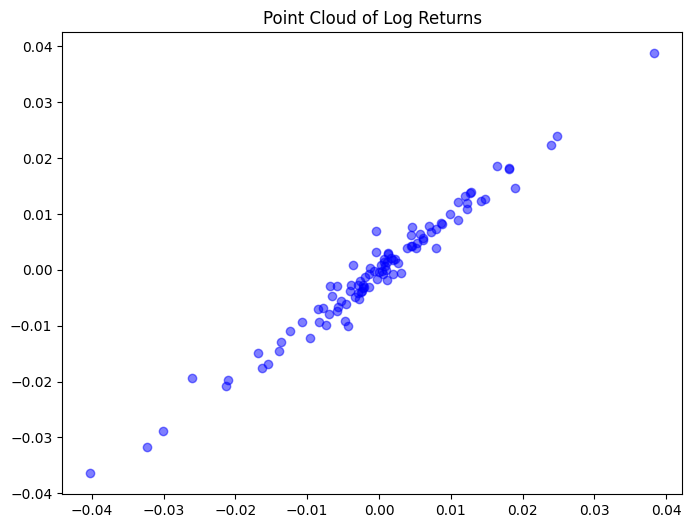

100%|██████████| 7692/7692 [00:15<00:00, 484.48it/s]


In [43]:
from tqdm import tqdm
import gudhi.representations as grepr

w = 100 # window size
diagrams_returns = []
for i in tqdm(range(w, len(log_returns))):
    window = log_returns.iloc[i-w:i].values  # shape (w, 4)
    rips = ripser.ripser(window)
    diagrams_returns.append(rips['dgms'])

    if i % 2000 == 0:
        # plot the point cloud of the current window
        plt.figure(figsize=(8, 6))
        plt.scatter(window[:, 0], window[:, 1], c='blue', alpha=0.5)
        plt.title(f"Point Cloud of Log Returns")
        plt.show()

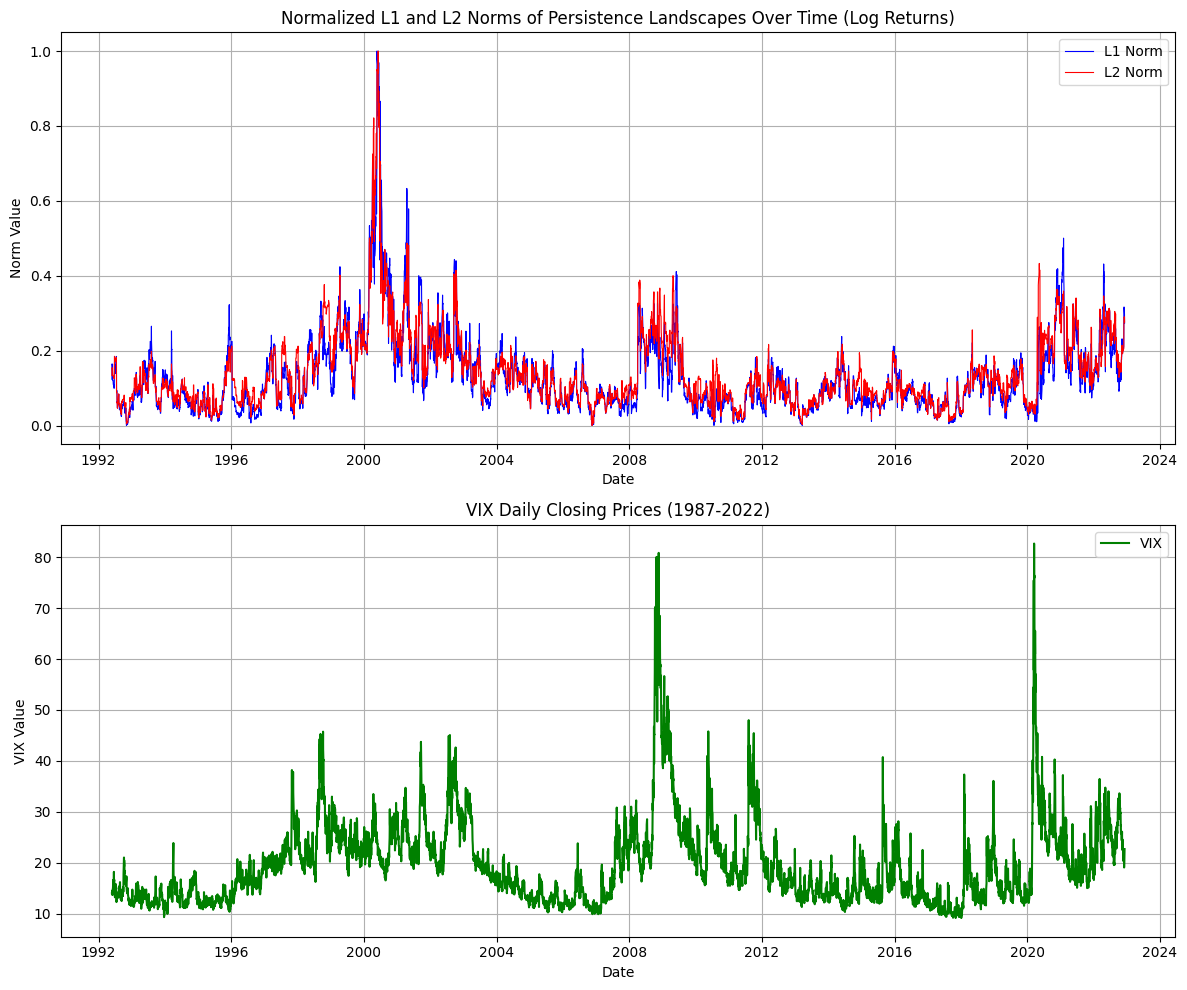

In [44]:
# on two subplots, one is normalized L1 and L2 norms of persistence landscapes over time, other is VIX time series
l1_norms_returns = []
l2_norms_returns = []
for diag in diagrams_returns:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms_returns.append(np.sum(np.abs(landscape)))
    l2_norms_returns.append(np.sqrt(np.sum(landscape**2)))

# normalize between 0 and 1
l1_norms_returns = (np.array(l1_norms_returns) - np.min(l1_norms_returns)) / (np.max(l1_norms_returns) - np.min(l1_norms_returns))
l2_norms_returns = (np.array(l2_norms_returns) - np.min(l2_norms_returns)) / (np.max(l2_norms_returns) - np.min(l2_norms_returns))

dates = log_returns.index

# on two subplots, one is both normalized L1 / L2 norms of persistence landscapes over time, other is VIX time series
plt.figure(figsize=(12, 10))
plt.axes1 = plt.subplot(2, 1, 1)
plt.plot(dates[w:], l1_norms_returns, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(dates[w:], l2_norms_returns, label='L2 Norm', color='red', linewidth=0.8)
plt.title("Normalized L1 and L2 Norms of Persistence Landscapes Over Time (Log Returns)")
plt.xlabel("Date")
plt.ylabel("Norm Value")
plt.legend()
plt.grid()
plt.axes2 = plt.subplot(2, 1, 2)
plt.plot(dates[w:], data.loc[dates[w:], '^VIX'], label='VIX', color='green')
plt.title("VIX Daily Closing Prices (1987-2022)")
plt.xlabel("Date")
plt.ylabel("VIX Value")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [51]:
# use the library ruptures to detect change points in the L2 norm time series.
import ruptures as rpt

l2_signal = l2_norms_returns.reshape(-1, 1)
model = "l2"
algo = rpt.Pelt(model=model).fit(l2_signal)
result = algo.predict(pen=3)

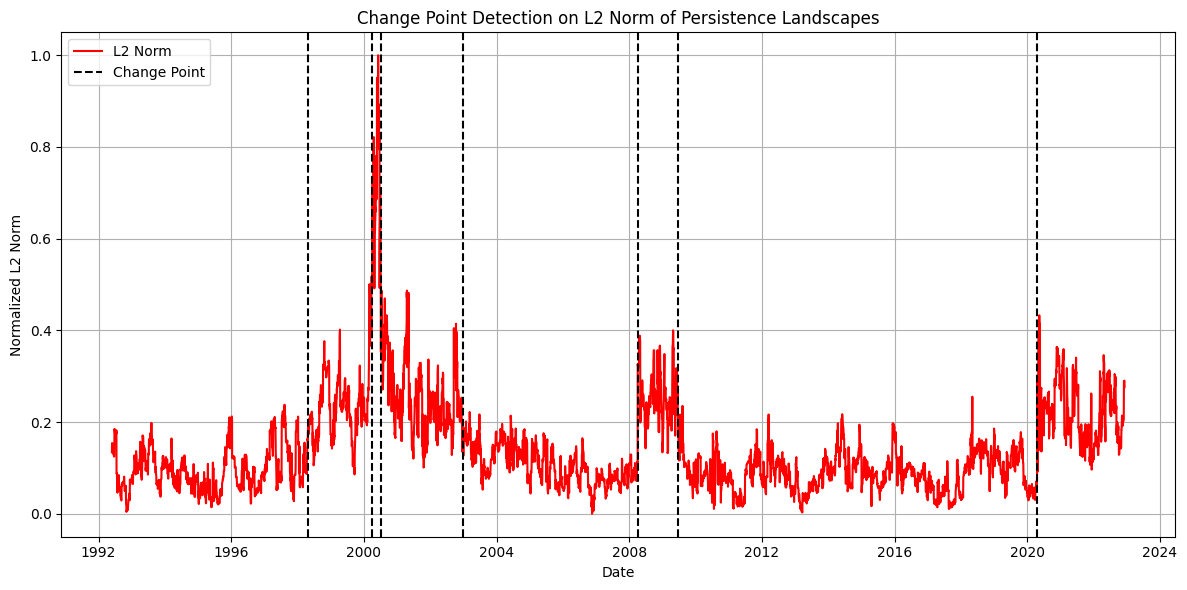

In [52]:
# plot the change points on the L2 norm time series
plt.figure(figsize=(12, 6))
plt.plot(dates[w:], l2_norms_returns, label='L2 Norm', color='red')
for cp in result[:-1]:
    plt.axvline(x=dates[w+cp], color='black', linestyle='--', label='Change Point' if cp == result[0] else "")
plt.title("Change Point Detection on L2 Norm of Persistence Landscapes")
plt.xlabel("Date")
plt.ylabel("Normalized L2 Norm")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [53]:
# find the dates of the detected change points
change_point_dates = [dates[w + cp] for cp in result[:-1]]
print("Detected Change Points Dates:")
for date in change_point_dates:
    print(date)

Detected Change Points Dates:
1998-04-27 00:00:00
2000-03-28 00:00:00
2000-07-07 00:00:00
2002-12-27 00:00:00
2008-04-04 00:00:00
2009-06-26 00:00:00
2020-04-17 00:00:00


In [ ]:
# compare to Lehman Brothers collapse date: September 15, 2008

# compare to covid crash date: March 16, 2020